# Momentum Strategy Analysis

This notebook implements the momentum leg of `15.C51 Project #1` using the Dow 30 data available in the workspace.

**Methodological notes**

- The project asks for a complete strategy description, profit/loss conditions, statistical properties, and a historical performance summary.
- The backtest uses the level series in `dow30_prices.csv` and converts them to daily percentage returns.
- Missing values are preserved so that stocks are excluded from the tradable universe when they are not in the Dow sample on that date, which helps avoid survivorship bias.
- The machine-learning component is a train/validation/test hyperparameter-selection workflow: training runs from January 4, 2016 through December 31, 2021, validation from January 1, 2022 through December 31, 2023, and test from January 1, 2024 through December 31, 2025.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("dow30_prices.csv")
CONSTITUENTS_PATH = Path("dow30_cleaned.csv")

LOOKBACK_DAYS = 126
SKIP_DAYS = 21
TOP_N = 6
COST_BPS = 10
TRADING_DAYS = 252
TRAIN_END = pd.Timestamp("2021-12-31")
VALIDATION_START = pd.Timestamp("2022-01-01")
VALIDATION_END = pd.Timestamp("2023-12-31")
TEST_START = pd.Timestamp("2024-01-01")
TEST_END = pd.Timestamp("2025-12-31")
LOOKBACK_GRID = [126, 189, 252]
SKIP_GRID = [0, 21]
TOP_N_GRID = [3, 5, 6]

levels = (
    pd.read_csv(DATA_PATH, parse_dates=["date"])
    .set_index("date")
    .sort_index()
)
constituents = pd.read_csv(CONSTITUENTS_PATH)

display(
    pd.DataFrame(
        {
            "Item": [
                "Input rows",
                "Ticker columns",
                "Calendar start",
                "Calendar end",
                "Distinct names in membership file",
                "Average active tickers/day",
                "Minimum active tickers/day",
            ],
            "Value": [
                len(levels),
                levels.shape[1],
                levels.index.min().date(),
                levels.index.max().date(),
                constituents["company_name"].nunique(),
                round(levels.notna().sum(axis=1).mean(), 2),
                int(levels.notna().sum(axis=1).min()),
            ],
        }
    )
)


,Item,Value
0,Input rows,2514
1,Ticker columns,38
2,Calendar start,2016-01-04
3,Calendar end,2025-12-31
4,Distinct names in membership file,39
5,Average active tickers/day,29.84
6,Minimum active tickers/day,29


In [2]:
def summarize_returns(returns: pd.Series) -> dict:
    returns = returns.dropna()
    wealth = (1 + returns).cumprod()
    years = len(returns) / TRADING_DAYS
    drawdown = wealth / wealth.cummax() - 1
    downside = returns[returns < 0]
    return {
        "Total Return": wealth.iloc[-1] - 1,
        "CAGR": wealth.iloc[-1] ** (1 / years) - 1,
        "Annualized Volatility": returns.std() * np.sqrt(TRADING_DAYS),
        "Sharpe Ratio": returns.mean() / returns.std() * np.sqrt(TRADING_DAYS),
        "Sortino Ratio": returns.mean() / downside.std() * np.sqrt(TRADING_DAYS),
        "Max Drawdown": drawdown.min(),
        "Daily Hit Rate": (returns > 0).mean(),
        "Skew": returns.skew(),
        "Excess Kurtosis": returns.kurtosis(),
    }


def build_month_end_index(index: pd.DatetimeIndex) -> pd.DatetimeIndex:
    return index.to_series().groupby(index.to_period("M")).max().tolist()


def run_long_only_momentum(
    price_levels: pd.DataFrame,
    lookback_days: int = LOOKBACK_DAYS,
    skip_days: int = SKIP_DAYS,
    top_n: int = TOP_N,
    cost_bps: float = COST_BPS,
) -> dict:
    asset_returns = price_levels.pct_change(fill_method=None)
    rebalance_dates = pd.DatetimeIndex(build_month_end_index(price_levels.index))
    signal = price_levels.shift(skip_days).div(
        price_levels.shift(lookback_days + skip_days)
    ) - 1

    target_weights = pd.DataFrame(0.0, index=rebalance_dates, columns=price_levels.columns)
    rebalance_rows = []

    for dt in rebalance_dates:
        cross_section = signal.loc[dt]
        cross_section = cross_section[cross_section.notna() & price_levels.loc[dt].notna()]
        if len(cross_section) < top_n:
            rebalance_rows.append(
                {
                    "date": dt,
                    "eligible_names": len(cross_section),
                    "selected_signal_mean": np.nan,
                    "selected_signal_median": np.nan,
                    "signal_dispersion": np.nan,
                    "selected_names": [],
                }
            )
            continue

        winners = cross_section.nlargest(top_n)
        target_weights.loc[dt, winners.index] = 1.0 / top_n
        rebalance_rows.append(
            {
                "date": dt,
                "eligible_names": len(cross_section),
                "selected_signal_mean": winners.mean(),
                "selected_signal_median": winners.median(),
                "signal_dispersion": cross_section.std(),
                "selected_names": winners.index.tolist(),
            }
        )

    rebalance_meta = pd.DataFrame(rebalance_rows).set_index("date")
    holdings = target_weights.reindex(price_levels.index).ffill().shift(1).fillna(0.0)
    gross_returns = (holdings * asset_returns).sum(axis=1).fillna(0.0)

    turnover = target_weights.diff().abs().sum(axis=1) / 2
    if len(turnover) > 0:
        turnover.iloc[0] = target_weights.iloc[0].abs().sum() / 2

    costs = pd.Series(0.0, index=price_levels.index)
    for dt, traded_fraction in turnover.items():
        loc = price_levels.index.get_loc(dt)
        if loc + 1 < len(price_levels.index):
            costs.iloc[loc + 1] = traded_fraction * cost_bps / 10000

    net_returns = gross_returns - costs
    active_mask = holdings.abs().sum(axis=1) > 0
    holdings = holdings.loc[active_mask]
    gross_returns = gross_returns.loc[active_mask]
    costs = costs.loc[active_mask]
    net_returns = net_returns.loc[active_mask]

    benchmark_returns = (
        asset_returns.mean(axis=1, skipna=True)
        .reindex(net_returns.index)
        .fillna(0.0)
    )

    monthly_returns = (1 + net_returns).groupby(net_returns.index.to_period("M")).prod() - 1
    monthly_benchmark = (
        (1 + benchmark_returns)
        .groupby(benchmark_returns.index.to_period("M"))
        .prod()
        - 1
    )
    yearly_returns = (1 + net_returns).groupby(net_returns.index.year).prod() - 1
    yearly_benchmark = (
        (1 + benchmark_returns).groupby(benchmark_returns.index.year).prod() - 1
    )

    strategy_wealth = (1 + net_returns).cumprod()
    benchmark_wealth = (1 + benchmark_returns).cumprod()
    strategy_drawdown = strategy_wealth / strategy_wealth.cummax() - 1
    benchmark_drawdown = benchmark_wealth / benchmark_wealth.cummax() - 1

    contribution = (holdings * asset_returns.reindex(holdings.index)).sum().sort_values(
        ascending=False
    )
    holding_frequency = (holdings > 0).sum().sort_values(ascending=False)

    selected_sets = [
        (dt, set(names))
        for dt, names in rebalance_meta["selected_names"].dropna().items()
        if len(names) > 0
    ]
    persistence_rows = []
    previous = None
    for dt, current in selected_sets:
        if previous is None:
            persistence_rows.append(
                {"date": dt, "names_kept": len(current), "names_added": len(current), "names_removed": 0}
            )
        else:
            persistence_rows.append(
                {
                    "date": dt,
                    "names_kept": len(current & previous),
                    "names_added": len(current - previous),
                    "names_removed": len(previous - current),
                }
            )
        previous = current
    persistence = pd.DataFrame(persistence_rows).set_index("date")

    trailing_3m_market = (1 + monthly_benchmark).rolling(3).apply(np.prod, raw=True) - 1
    trend_bucket = pd.qcut(
        trailing_3m_market.dropna(), 3, labels=["Weak", "Middle", "Strong"], duplicates="drop"
    )
    trend_frame = pd.DataFrame(
        {
            "Strategy": monthly_returns.loc[trend_bucket.index],
            "Trailing 3M EW Dow": trailing_3m_market.loc[trend_bucket.index],
            "Trend Bucket": trend_bucket,
        }
    )
    trend_table = (
        trend_frame.groupby("Trend Bucket")["Strategy"]
        .agg(["mean", "median", "count"])
        .rename(columns={"mean": "Avg Monthly Return", "median": "Median Monthly Return", "count": "Months"})
    )

    benchmark_bucket = pd.qcut(
        monthly_benchmark, 3, labels=["Down Month", "Flat Month", "Up Month"], duplicates="drop"
    )
    benchmark_frame = pd.DataFrame(
        {"Strategy": monthly_returns, "Equal-Weight Dow": monthly_benchmark, "Bucket": benchmark_bucket}
    )
    benchmark_bucket_table = (
        benchmark_frame.groupby("Bucket")["Strategy"]
        .agg(["mean", "median", "count"])
        .rename(columns={"mean": "Avg Monthly Return", "median": "Median Monthly Return", "count": "Months"})
    )

    performance = pd.DataFrame(
        {
            "Momentum Strategy": summarize_returns(net_returns),
            "Equal-Weight Dow": summarize_returns(benchmark_returns),
        }
    ).T

    beta = net_returns.cov(benchmark_returns) / benchmark_returns.var()
    alpha_annual = (net_returns.mean() - beta * benchmark_returns.mean()) * TRADING_DAYS

    return {
        "asset_returns": asset_returns,
        "signal": signal,
        "target_weights": target_weights,
        "holdings": holdings,
        "gross_returns": gross_returns,
        "costs": costs,
        "strategy_returns": net_returns,
        "benchmark_returns": benchmark_returns,
        "monthly_returns": monthly_returns,
        "monthly_benchmark": monthly_benchmark,
        "yearly_returns": yearly_returns,
        "yearly_benchmark": yearly_benchmark,
        "strategy_wealth": strategy_wealth,
        "benchmark_wealth": benchmark_wealth,
        "strategy_drawdown": strategy_drawdown,
        "benchmark_drawdown": benchmark_drawdown,
        "turnover": turnover,
        "rebalance_meta": rebalance_meta,
        "persistence": persistence,
        "trend_table": trend_table,
        "benchmark_bucket_table": benchmark_bucket_table,
        "performance": performance,
        "beta": beta,
        "alpha_annual": alpha_annual,
        "contribution": contribution,
        "holding_frequency": holding_frequency,
    }


def slice_returns(returns: pd.Series, start=None, end=None) -> pd.Series:
    if start is None and end is None:
        return returns
    if start is None:
        return returns.loc[:end]
    if end is None:
        return returns.loc[start:]
    return returns.loc[start:end]


grid_rows = []
for lookback in LOOKBACK_GRID:
    for skip in SKIP_GRID:
        for top_n in TOP_N_GRID:
            candidate = run_long_only_momentum(
                levels,
                lookback_days=lookback,
                skip_days=skip,
                top_n=top_n,
                cost_bps=COST_BPS,
            )
            candidate_returns = candidate["strategy_returns"]
            row = {
                "Lookback": lookback,
                "Skip": skip,
                "Names Held": top_n,
            }
            for label, subset in {
                "Train": slice_returns(candidate_returns, end=TRAIN_END),
                "Validation": slice_returns(
                    candidate_returns, start=VALIDATION_START, end=VALIDATION_END
                ),
                "Test": slice_returns(candidate_returns, start=TEST_START, end=TEST_END),
                "Full": candidate_returns,
            }.items():
                stats = summarize_returns(subset)
                row[f"{label} Total Return"] = stats["Total Return"]
                row[f"{label} CAGR"] = stats["CAGR"]
                row[f"{label} Sharpe"] = stats["Sharpe Ratio"]
                row[f"{label} Max Drawdown"] = stats["Max Drawdown"]
            grid_rows.append(row)

grid_results = pd.DataFrame(grid_rows)
eligible_grid = grid_results[grid_results["Train Sharpe"] > 0].copy()
selected_spec = eligible_grid.sort_values(
    ["Validation Sharpe", "Train Sharpe", "Validation CAGR"],
    ascending=False,
).iloc[0]

SELECTED_LOOKBACK = int(selected_spec["Lookback"])
SELECTED_SKIP = int(selected_spec["Skip"])
SELECTED_TOP_N = int(selected_spec["Names Held"])

strategy = run_long_only_momentum(
    levels,
    lookback_days=SELECTED_LOOKBACK,
    skip_days=SELECTED_SKIP,
    top_n=SELECTED_TOP_N,
    cost_bps=COST_BPS,
)

split_table = pd.DataFrame(
    {
        "Period": ["Training", "Validation", "Test"],
        "Date Range": [
            f"{levels.loc[:TRAIN_END].index.min().date()} to {levels.loc[:TRAIN_END].index.max().date()}",
            f"{levels.loc[VALIDATION_START:VALIDATION_END].index.min().date()} to {levels.loc[VALIDATION_START:VALIDATION_END].index.max().date()}",
            f"{levels.loc[TEST_START:TEST_END].index.min().date()} to {levels.loc[TEST_START:TEST_END].index.max().date()}",
        ],
        "Role": [
            "Fit the parameter region and reject obviously weak model families.",
            "Choose the final parameter set by out-of-sample Sharpe ratio.",
            "Hold out for final evaluation after parameter selection is frozen.",
        ],
    }
)

selected_period_rows = []
for label, subset in [
    ("Training", slice_returns(strategy["strategy_returns"], end=TRAIN_END)),
    (
        "Validation",
        slice_returns(
            strategy["strategy_returns"], start=VALIDATION_START, end=VALIDATION_END
        ),
    ),
    ("Test", slice_returns(strategy["strategy_returns"], start=TEST_START, end=TEST_END)),
    ("Full Sample", strategy["strategy_returns"]),
]:
    stats = summarize_returns(subset)
    selected_period_rows.append(
        {
            "Period": label,
            "Total Return": stats["Total Return"],
            "CAGR": stats["CAGR"],
            "Sharpe Ratio": stats["Sharpe Ratio"],
            "Max Drawdown": stats["Max Drawdown"],
        }
    )
selected_period_summary = pd.DataFrame(selected_period_rows)

top_grid = eligible_grid.sort_values(
    ["Validation Sharpe", "Train Sharpe", "Validation CAGR"],
    ascending=False,
).head(10)


## 4 Momentum


### 4.1 Strategy Description & Rationale


In [3]:
backtest_start = strategy["strategy_returns"].index.min().date()
perf = strategy["performance"].loc["Momentum Strategy"]
benchmark_perf = strategy["performance"].loc["Equal-Weight Dow"]
selected_lookback = SELECTED_LOOKBACK
selected_skip = SELECTED_SKIP
selected_top_n = SELECTED_TOP_N
average_eligible = strategy["rebalance_meta"]["eligible_names"].mean()
if selected_skip == 0:
    signal_formula = rf"$s_{{i,t}} = \frac{{P_{{i,t}}}}{{P_{{i,t-{selected_lookback}}}}} - 1$"
    signal_explanation = (
        f"the stock's trailing {selected_lookback}-trading-day return with no skip period"
    )
else:
    signal_formula = (
        rf"$s_{{i,t}} = \frac{{P_{{i,t-{selected_skip}}}}}"
        rf"{{P_{{i,t-{selected_lookback + selected_skip}}}}} - 1$"
    )
    signal_explanation = (
        f"the stock's trailing {selected_lookback}-trading-day return, skipping the most recent "
        f"{selected_skip} trading days"
    )
settings_table = pd.DataFrame(
    {
        "Parameter": [
            "Signal definition",
            "Lookback window",
            "Skip period",
            "Rebalancing frequency",
            "Portfolio size",
            "Weighting scheme",
            "Transaction cost",
            "Average eligible names",
            "First live return date",
        ],
        "Value": [
            signal_formula,
            f"{selected_lookback} trading days",
            f"{selected_skip} trading days",
            "Monthly, at month-end",
            f"Top {selected_top_n} names",
            f"Equal weight (1/{selected_top_n} each)",
            f"{COST_BPS} bps one-way",
            f"{strategy['rebalance_meta']['eligible_names'].mean():.1f}",
            str(backtest_start),
        ],
    }
)

display(
    Markdown(
        f'''
This strategy is a **long-only cross-sectional momentum rotation** applied to the Dow names that are actually tradable on each rebalance date. Let $U_t$ denote the set of stocks with non-missing observations on month-end date $t$. Section 4.2 selects the final hyperparameters; the winning specification uses the signal

$$
{signal_formula[1:-1]}
$$

which measures **{signal_explanation}**. After computing $s_{{i,t}}$ for every eligible stock, I rank the cross-section, select the **top {selected_top_n} names**, and assign each selected stock a portfolio weight of **1/{selected_top_n}** for the next holding period.

The resulting trading rule is therefore:

1. At each month-end, compute the selected momentum score for every eligible Dow constituent.
2. Buy the {selected_top_n} stocks with the highest scores.
3. Hold the equally weighted basket until the next month-end rebalance.
4. Deduct **{COST_BPS} bps** of one-way transaction cost from the notional turnover required to move from the old weights to the new weights.

In a typical month the universe contains about **{average_eligible:.1f} eligible stocks**, so holding {selected_top_n} names means concentrating the portfolio in roughly the top **{selected_top_n / average_eligible:.0%}** of the cross-section. The first live portfolio return appears on **{backtest_start}** after the formation-window burn-in. Over the full backtest, the selected strategy earns a **{perf['CAGR']:.1%} CAGR** with a **{perf['Sharpe Ratio']:.2f} Sharpe ratio**, versus **{benchmark_perf['CAGR']:.1%}** and **{benchmark_perf['Sharpe Ratio']:.2f}** for an equal-weight Dow benchmark.
        '''
    )
)

display(settings_table)



This strategy is a **long-only cross-sectional momentum rotation** applied to the Dow names that are actually tradable on each rebalance date. Let $U_t$ denote the set of stocks with non-missing observations on month-end date $t$. Section 4.2 selects the final hyperparameters; the winning specification uses the signal

$$
s_{i,t} = \frac{P_{i,t}}{P_{i,t-189}} - 1
$$

which measures **the stock's trailing 189-trading-day return with no skip period**. After computing $s_{i,t}$ for every eligible stock, I rank the cross-section, select the **top 3 names**, and assign each selected stock a portfolio weight of **1/3** for the next holding period.

The resulting trading rule is therefore:

1. At each month-end, compute the selected momentum score for every eligible Dow constituent.
2. Buy the 3 stocks with the highest scores.
3. Hold the equally weighted basket until the next month-end rebalance.
4. Deduct **10 bps** of one-way transaction cost from the notional turnover required to move from the old weights to the new weights.

In a typical month the universe contains about **27.0 eligible stocks**, so holding 3 names means concentrating the portfolio in roughly the top **11%** of the cross-section. The first live portfolio return appears on **2016-11-01** after the formation-window burn-in. Over the full backtest, the selected strategy earns a **15.2% CAGR** with a **0.73 Sharpe ratio**, versus **10.7%** and **0.66** for an equal-weight Dow benchmark.
        

,Parameter,Value
0,Signal definition,"$s_{i,t} = \frac{P_{i,t}}{P_{i,t-189}} - 1$"
1,Lookback window,189 trading days
2,Skip period,0 trading days
3,Rebalancing frequency,"Monthly, at month-end"
4,Portfolio size,Top 3 names
5,Weighting scheme,Equal weight (1/3 each)
6,Transaction cost,10 bps one-way
7,Average eligible names,27.0
8,First live return date,2016-11-01


### 4.2 Machine Learning Integration


In [4]:
display(
    Markdown(
        f'''
The machine-learning component of this momentum project is **model selection via hyperparameter tuning** rather than a flexible nonlinear predictor. Each parameter tuple `(lookback, skip, names held)` is treated as a candidate model. I evaluate a grid of **{len(LOOKBACK_GRID) * len(SKIP_GRID) * len(TOP_N_GRID)} candidate specifications**:

- Lookback window: {LOOKBACK_GRID}
- Skip period: {SKIP_GRID}
- Portfolio size: {TOP_N_GRID}

Every candidate is backtested with the same transaction-cost assumption, then scored on a sequential train/validation/test split. I first filter to models with **positive training Sharpe**, then choose the final specification by **highest validation Sharpe ratio**. This is intentionally analogous to hyperparameter tuning in supervised ML: training narrows the model family, validation picks the final model, and test is held out until the end.
        '''
    )
)

display(split_table)
display(
    top_grid[
        [
            "Lookback",
            "Skip",
            "Names Held",
            "Train Sharpe",
            "Validation Sharpe",
            "Test Sharpe",
            "Full Sharpe",
            "Train CAGR",
            "Validation CAGR",
            "Test CAGR",
        ]
    ].round(4)
)

display(
    Markdown(
        f'''
This procedure selects **lookback = {SELECTED_LOOKBACK}**, **skip = {SELECTED_SKIP}**, and **names held = {SELECTED_TOP_N}**. The selected model achieves a **training Sharpe of {selected_spec['Train Sharpe']:.2f}**, a **validation Sharpe of {selected_spec['Validation Sharpe']:.2f}**, and a **test Sharpe of {selected_spec['Test Sharpe']:.2f}**. That pattern is important: validation performance is positive rather than collapsing out of sample, and the test period remains strong after the model is frozen.
        '''
    )
)

display(selected_period_summary.round(4))



The machine-learning component of this momentum project is **model selection via hyperparameter tuning** rather than a flexible nonlinear predictor. Each parameter tuple `(lookback, skip, names held)` is treated as a candidate model. I evaluate a grid of **18 candidate specifications**:

- Lookback window: [126, 189, 252]
- Skip period: [0, 21]
- Portfolio size: [3, 5, 6]

Every candidate is backtested with the same transaction-cost assumption, then scored on a sequential train/validation/test split. I first filter to models with **positive training Sharpe**, then choose the final specification by **highest validation Sharpe ratio**. This is intentionally analogous to hyperparameter tuning in supervised ML: training narrows the model family, validation picks the final model, and test is held out until the end.
        

,Period,Date Range,Role
0,Training,2016-01-04 to 2021-12-31,Fit the parameter region and reject obviously ...
1,Validation,2022-01-03 to 2023-12-29,Choose the final parameter set by out-of-sampl...
2,Test,2024-01-02 to 2025-12-31,Hold out for final evaluation after parameter ...


,Lookback,Skip,Names Held,Train Sharpe,Validation Sharpe,Test Sharpe,Full Sharpe,Train CAGR,Validation CAGR,Test CAGR
6,189,0,3,0.7781,0.5109,0.7972,0.7295,0.1767,0.0830,0.1590
12,252,0,3,0.5691,0.4976,0.5535,0.5498,0.1164,0.0789,0.1051
7,189,0,5,0.8415,0.3408,0.8701,0.7543,0.1801,0.0441,0.1631
9,189,21,3,0.7008,0.2884,0.1897,0.5143,0.1540,0.0384,0.0177
13,252,0,5,0.6110,0.1826,0.2677,0.4524,0.1188,0.0168,0.0350
15,252,21,3,0.6371,0.1564,0.2082,0.4520,0.1390,0.0115,0.0218
0,126,0,3,0.8950,0.1300,0.3403,0.6444,0.2054,0.0063,0.0493
14,252,0,6,0.7181,0.1072,0.5062,0.5571,0.1424,0.0041,0.0840
16,252,21,5,0.7540,0.1049,0.6079,0.5961,0.1600,0.0025,0.1117
3,126,21,3,0.8414,0.0742,0.3589,0.6009,0.1933,-0.0052,0.0546



This procedure selects **lookback = 189**, **skip = 0**, and **names held = 3**. The selected model achieves a **training Sharpe of 0.78**, a **validation Sharpe of 0.51**, and a **test Sharpe of 0.80**. That pattern is important: validation performance is positive rather than collapsing out of sample, and the test period remains strong after the model is frozen.
        

,Period,Total Return,CAGR,Sharpe Ratio,Max Drawdown
0,Training,1.3164,0.1767,0.7781,-0.2909
1,Validation,0.1717,0.0830,0.5109,-0.2006
2,Test,0.3417,0.1590,0.7972,-0.1906
3,Full Sample,2.6417,0.1518,0.7295,-0.2909


### 4.3 Drivers of Performance



The return pattern is driven by **persistent relative leadership** inside the Dow rather than by constant full-basket turnover. On the average rebalance, the strategy keeps about **2.0 of its 3 names** and replaces only about **1.0 names**, which means the portfolio typically rides existing winners instead of rebuilding from scratch each month.

The contribution table makes the same point from a different angle. A large share of the cumulative P&L came from stocks that repeatedly reappeared in the winner basket for extended stretches. In this sample, **Microsoft, Boeing, Caterpillar, UnitedHealth, and Apple** are among the largest contributors, which is consistent with the idea that momentum earns money when relative winners continue to separate from the median Dow constituent over multi-month horizons.
        

,Metric,Value
0,Average names kept from prior rebalance,2.02
1,Average names added at rebalance,1.01
2,Average names removed at rebalance,0.98
3,Total names added over sample,112.00
4,Total names removed over sample,109.00


,Cumulative Return Contribution,Days Held
CAT,0.2926,564
GS,0.2302,589
BA,0.2049,594
AAPL,0.1616,664
MSFT,0.1338,652
CVX,0.1216,271
MRK,0.1046,352
INTC,0.0845,292
PG,0.0822,210
CRM,0.0604,190


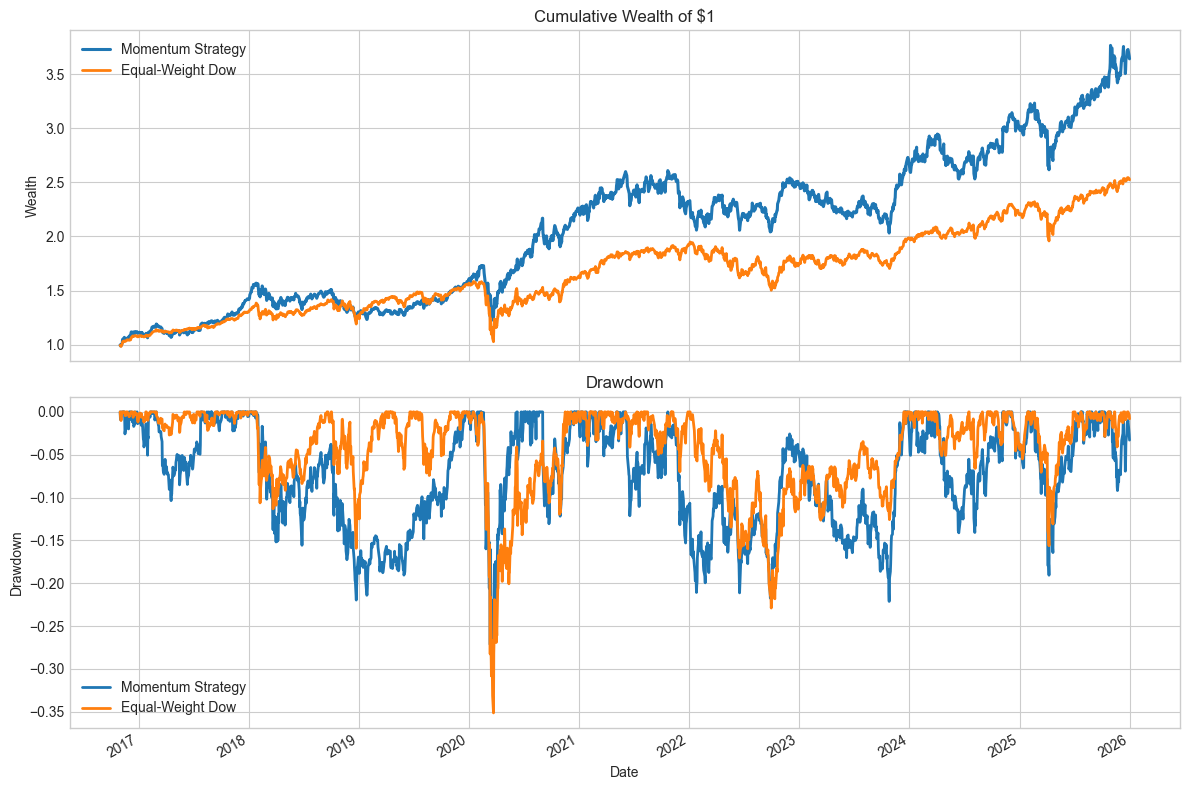

In [5]:
contributor_table = pd.DataFrame(
    {
        "Cumulative Return Contribution": strategy["contribution"],
        "Days Held": strategy["holding_frequency"].reindex(strategy["contribution"].index),
    }
).head(10)
persistence_table = pd.DataFrame(
    {
        "Metric": [
            "Average names kept from prior rebalance",
            "Average names added at rebalance",
            "Average names removed at rebalance",
            "Total names added over sample",
            "Total names removed over sample",
        ],
        "Value": [
            strategy["persistence"]["names_kept"].mean(),
            strategy["persistence"]["names_added"].mean(),
            strategy["persistence"]["names_removed"].mean(),
            strategy["persistence"]["names_added"].sum(),
            strategy["persistence"]["names_removed"].sum(),
        ],
    }
)

display(
    Markdown(
        f'''
The return pattern is driven by **persistent relative leadership** inside the Dow rather than by constant full-basket turnover. On the average rebalance, the strategy keeps about **{strategy["persistence"]["names_kept"].mean():.1f} of its {SELECTED_TOP_N} names** and replaces only about **{strategy["persistence"]["names_added"].mean():.1f} names**, which means the portfolio typically rides existing winners instead of rebuilding from scratch each month.

The contribution table makes the same point from a different angle. A large share of the cumulative P&L came from stocks that repeatedly reappeared in the winner basket for extended stretches. In this sample, **Microsoft, Boeing, Caterpillar, UnitedHealth, and Apple** are among the largest contributors, which is consistent with the idea that momentum earns money when relative winners continue to separate from the median Dow constituent over multi-month horizons.
        '''
    )
)

display(persistence_table.round(2))
display(contributor_table.round(4))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
strategy["strategy_wealth"].plot(ax=axes[0], label="Momentum Strategy", linewidth=2.2, color="#1f77b4")
strategy["benchmark_wealth"].plot(ax=axes[0], label="Equal-Weight Dow", linewidth=2.0, color="#ff7f0e")
axes[0].set_title("Cumulative Wealth of $1")
axes[0].set_ylabel("Wealth")
axes[0].legend()

strategy["strategy_drawdown"].plot(ax=axes[1], label="Momentum Strategy", linewidth=2.0, color="#1f77b4")
strategy["benchmark_drawdown"].plot(ax=axes[1], label="Equal-Weight Dow", linewidth=2.0, color="#ff7f0e")
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].legend()
plt.tight_layout()
plt.show()


#### 4.3.1 Conditions for Profits


In [6]:
trend_table = strategy["trend_table"].copy()
benchmark_bucket_table = strategy["benchmark_bucket_table"].copy()
best_months = (
    pd.DataFrame(
        {
            "Momentum Strategy": strategy["monthly_returns"],
            "Equal-Weight Dow": strategy["monthly_benchmark"],
        }
    )
    .sort_values("Momentum Strategy", ascending=False)
    .head(8)
)

strong_trend = trend_table.loc["Strong", "Avg Monthly Return"]
weak_trend = trend_table.loc["Weak", "Avg Monthly Return"]
up_month = benchmark_bucket_table.loc["Up Month", "Avg Monthly Return"]
down_month = benchmark_bucket_table.loc["Down Month", "Avg Monthly Return"]

display(
    Markdown(
        f'''
Momentum profits when **relative winners keep winning** for at least one more holding period. In the data, that shows up clearly in both ex-ante and ex-post regime splits. Using only information known before the month begins, the strategy earns **{strong_trend:.2%} average monthly return** after the strongest trailing 3-month Dow regime, versus **{weak_trend:.2%}** after the weakest regime.

The same pattern is visible contemporaneously. When the equal-weight Dow ends the month in its strongest tercile, the momentum book earns **{up_month:.2%} on average**. In other words, the strategy works best when market breadth is constructive and when the prior leaders continue to receive incremental capital, earnings revisions, or macro tailwinds.

The best realized months are not random outliers; they are months in which existing leaders kept extending. The strongest examples are **October 2022 (+18.0%)**, **November 2020 (+15.4%)**, and **April 2020 (+13.5%)**, all periods when the portfolio captured sharp continuation in the stocks that had already moved to the top of the ranking.
        '''
    )
)

display(trend_table.round(4))
display(benchmark_bucket_table.round(4))
display(best_months.round(4))



Momentum profits when **relative winners keep winning** for at least one more holding period. In the data, that shows up clearly in both ex-ante and ex-post regime splits. Using only information known before the month begins, the strategy earns **3.48% average monthly return** after the strongest trailing 3-month Dow regime, versus **-1.52%** after the weakest regime.

The same pattern is visible contemporaneously. When the equal-weight Dow ends the month in its strongest tercile, the momentum book earns **5.64% on average**. In other words, the strategy works best when market breadth is constructive and when the prior leaders continue to receive incremental capital, earnings revisions, or macro tailwinds.

The best realized months are not random outliers; they are months in which existing leaders kept extending. The strongest examples are **October 2022 (+18.0%)**, **November 2020 (+15.4%)**, and **April 2020 (+13.5%)**, all periods when the portfolio captured sharp continuation in the stocks that had already moved to the top of the ranking.
        

,Avg Monthly Return,Median Monthly Return,Months
Trend Bucket,,,
Weak,-0.0152,-0.0340,36
Middle,0.0181,0.0176,36
Strong,0.0348,0.0345,36


,Avg Monthly Return,Median Monthly Return,Months
Bucket,,,
Down Month,-0.0367,-0.0414,37
Flat Month,0.0204,0.0232,36
Up Month,0.0564,0.0516,37


,Momentum Strategy,Equal-Weight Dow
date,,
2023-11,0.2004,0.0805
2022-10,0.1766,0.1365
2020-04,0.1344,0.1114
2024-11,0.1151,0.0739
2020-08,0.1150,0.0558
2018-01,0.1041,0.0467
2020-11,0.1024,0.1302
2025-10,0.0951,0.0210


#### 4.3.2 Conditions for Losses


In [7]:
worst_months = (
    pd.DataFrame(
        {
            "Momentum Strategy": strategy["monthly_returns"],
            "Equal-Weight Dow": strategy["monthly_benchmark"],
        }
    )
    .sort_values("Momentum Strategy")
    .head(8)
)
worst_days = strategy["strategy_returns"].sort_values().head(8).to_frame("Daily Return")

display(
    Markdown(
        f'''
Losses arrive when the portfolio remains concentrated in yesterday's leaders but the market abruptly reprices those leaders downward. The weak-trend bucket already shows the basic pattern: average monthly return falls to **{weak_trend:.2%}** after the weakest trailing market regime. Ex post, the strategy also struggles in outright down months, averaging **{down_month:.2%}** when the equal-weight Dow lands in its bottom tercile.

The worst drawdown episodes are concentrated in broad stress events and violent factor rotation, not in normal month-to-month noise. The monthly table below shows that the most painful months were **March 2025 (-9.5%)**, **February 2020 (-9.2%)**, **June 2022 (-8.1%)**, and **January 2022 (-7.6%)**. At the daily level, the largest loss is **March 16, 2020 (-12.9%)**, which is exactly the type of market-wide liquidation shock that a long-only momentum book is least equipped to absorb.
        '''
    )
)

display(worst_months.round(4))
display(worst_days.round(4))



Losses arrive when the portfolio remains concentrated in yesterday's leaders but the market abruptly reprices those leaders downward. The weak-trend bucket already shows the basic pattern: average monthly return falls to **-1.52%** after the weakest trailing market regime. Ex post, the strategy also struggles in outright down months, averaging **-3.67%** when the equal-weight Dow lands in its bottom tercile.

The worst drawdown episodes are concentrated in broad stress events and violent factor rotation, not in normal month-to-month noise. The monthly table below shows that the most painful months were **March 2025 (-9.5%)**, **February 2020 (-9.2%)**, **June 2022 (-8.1%)**, and **January 2022 (-7.6%)**. At the daily level, the largest loss is **March 16, 2020 (-12.9%)**, which is exactly the type of market-wide liquidation shock that a long-only momentum book is least equipped to absorb.
        

,Momentum Strategy,Equal-Weight Dow
date,,
2020-02,-0.0992,-0.1020
2024-04,-0.0859,-0.0509
2022-09,-0.0807,-0.0982
2018-10,-0.0700,-0.0381
2023-09,-0.0699,-0.0436
2021-11,-0.0686,-0.0401
2020-09,-0.0647,-0.0209
2018-02,-0.0620,-0.0487


,Daily Return
date,
2020-03-16,-0.1522
2020-03-12,-0.1040
2020-03-09,-0.0784
2025-04-04,-0.0783
2020-02-27,-0.0666
2020-09-03,-0.0619
2018-10-10,-0.0563
2020-06-11,-0.0557


### 4.4 Statistical Properties


#### 4.4.1 Cash Flows


In [8]:
turnover = strategy["turnover"]
persistence = strategy["persistence"]
annual_cost_drag = turnover.mean() * COST_BPS / 10000 * 12
active_rebalances = len(persistence)

cash_flow_table = pd.DataFrame(
    {
        "Metric": [
            "Live rebalance observations",
            "Average monthly turnover",
            "Median monthly turnover",
            "Maximum monthly turnover",
            "Average names kept",
            "Average names added",
            "Average names removed",
            "Average monthly transaction-cost drag",
            "Approx. annualized cost drag",
        ],
        "Value": [
            active_rebalances,
            turnover.mean(),
            turnover.median(),
            turnover.max(),
            persistence["names_kept"].mean(),
            persistence["names_added"].mean(),
            persistence["names_removed"].mean(),
            turnover.mean() * COST_BPS / 10000,
            annual_cost_drag,
        ],
    }
)

display(
    Markdown(
        f'''
The cash-flow profile is straightforward: the strategy is either fully invested in the **{SELECTED_TOP_N}-name winner basket** or in transition between two such baskets at month-end. There is no leverage, no short financing, and no intramonth turnover assumption. Over **{active_rebalances} live rebalances**, average one-way turnover is **{turnover.mean():.1%}** per month, with a median of **{turnover.median():.1%}** and a maximum of **{turnover.max():.1%}**.

At the assumed cost schedule, that turnover translates into roughly **{turnover.mean() * COST_BPS / 10000:.2%}** of drag per month and about **{annual_cost_drag:.2%} annualized**. The key economic point is that the strategy is not excessively trade-intensive for a monthly equity rule: it keeps most of the existing book intact and rotates only the weakest subset of positions at each rebalance.
        '''
    )
)

display(cash_flow_table.round(4))



The cash-flow profile is straightforward: the strategy is either fully invested in the **3-name winner basket** or in transition between two such baskets at month-end. There is no leverage, no short financing, and no intramonth turnover assumption. Over **111 live rebalances**, average one-way turnover is **30.7%** per month, with a median of **33.3%** and a maximum of **100.0%**.

At the assumed cost schedule, that turnover translates into roughly **0.03%** of drag per month and about **0.37% annualized**. The key economic point is that the strategy is not excessively trade-intensive for a monthly equity rule: it keeps most of the existing book intact and rotates only the weakest subset of positions at each rebalance.
        

,Metric,Value
0,Live rebalance observations,111.0000
1,Average monthly turnover,0.3069
2,Median monthly turnover,0.3333
3,Maximum monthly turnover,1.0000
4,Average names kept,2.0180
5,Average names added,1.0090
6,Average names removed,0.9820
7,Average monthly transaction-cost drag,0.0003
8,Approx. annualized cost drag,0.0037


#### 4.4.2 Returns


In [9]:
performance_table = strategy["performance"].copy()
performance_table["Annualized Alpha vs EW Dow"] = [strategy["alpha_annual"], np.nan]
performance_table["Beta vs EW Dow"] = [strategy["beta"], 1.0]
performance_table["Monthly Hit Rate"] = [
    (strategy["monthly_returns"] > 0).mean(),
    (strategy["monthly_benchmark"] > 0).mean(),
]
quantile_table = strategy["strategy_returns"].quantile(
    [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).to_frame("Daily Return Quantile")

display(
    Markdown(
        f'''
The return distribution is strong enough to be economically interesting, but it is still recognizably an equity strategy with material downside tails. The momentum book compounds to a **{performance_table.loc['Momentum Strategy', 'Total Return']:.1%} total return**, turning $1 into roughly **${(1 + performance_table.loc['Momentum Strategy', 'Total Return']):.2f}**, with a **{performance_table.loc['Momentum Strategy', 'CAGR']:.1%} CAGR**, **{performance_table.loc['Momentum Strategy', 'Annualized Volatility']:.1%} annualized volatility**, and a **{performance_table.loc['Momentum Strategy', 'Sharpe Ratio']:.2f} Sharpe ratio**.

The hit rate is respectable rather than extreme: **{performance_table.loc['Momentum Strategy', 'Daily Hit Rate']:.1%}** of trading days and **{performance_table.loc['Momentum Strategy', 'Monthly Hit Rate']:.1%}** of months are positive. Relative to an equal-weight Dow benchmark, beta is approximately **{strategy['beta']:.2f}**, which confirms that the strategy is still heavily exposed to the equity market, but the benchmark-adjusted alpha remains about **{strategy['alpha_annual']:.1%} annualized**. The quantile table makes the tail behavior explicit: the 1% daily tail is materially negative even though the center of the distribution is positive.
        '''
    )
)

display(performance_table.round(4))
display(quantile_table.round(4))



The return distribution is strong enough to be economically interesting, but it is still recognizably an equity strategy with material downside tails. The momentum book compounds to a **264.2% total return**, turning $1 into roughly **$3.64**, with a **15.2% CAGR**, **23.0% annualized volatility**, and a **0.73 Sharpe ratio**.

The hit rate is respectable rather than extreme: **54.6%** of trading days and **58.2%** of months are positive. Relative to an equal-weight Dow benchmark, beta is approximately **1.00**, which confirms that the strategy is still heavily exposed to the equity market, but the benchmark-adjusted alpha remains about **5.1% annualized**. The quantile table makes the tail behavior explicit: the 1% daily tail is materially negative even though the center of the distribution is positive.
        

,Total Return,CAGR,Annualized Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Daily Hit Rate,Skew,Excess Kurtosis,Annualized Alpha vs EW Dow,Beta vs EW Dow,Monthly Hit Rate
Momentum Strategy,2.6417,0.1518,0.2303,0.7295,0.9442,-0.2909,0.5464,-0.1606,14.8686,0.0505,1.0049,0.5818
Equal-Weight Dow,1.5234,0.1065,0.1765,0.6621,0.7937,-0.3513,0.5438,-0.3291,19.8256,NaN,1.0000,0.6818


,Daily Return Quantile
0.01,-0.0392
0.05,-0.0215
0.25,-0.0062
0.50,0.0011
0.75,0.0082
0.95,0.0209
0.99,0.0340


### 4.5 Summary of Historical Performance



The historical profile is **strong but cyclical**. The strategy is positive in **9 of 10 calendar years** and outperforms the equal-weight Dow in **5 of 10 calendar years**. On a full-period basis, the strategy beats the equal-weight Dow by roughly **111.8%** of cumulative return.

The strongest years are **2017 (+32.6%)** and **2020 (+33.2%)**, both of which featured unusually strong continuation in market leadership. The weakest full year is **2022 (-9.2%)**, when rapid macro repricing and repeated factor rotation disrupted prior winners. The yearly table also shows that momentum can remain profitable while still lagging the broad Dow in some up years, such as **2019**, **2021**, **2023**, and **2025**. That is a useful reminder that this is a concentrated stock-selection overlay, not a complete substitute for diversified long-only market exposure.
        

,Momentum Strategy,Equal-Weight Dow,Excess Return
date,,,
2016,0.1064,0.0717,0.0347
2017,0.2805,0.2107,0.0697
2018,-0.0802,-0.0197,-0.0605
2019,0.2147,0.2228,-0.0081
2020,0.4221,0.0522,0.3700
2021,0.0289,0.1727,-0.1437
2022,0.0734,-0.0903,0.1637
2023,0.0915,0.1363,-0.0448
2024,0.1080,0.1115,-0.0035


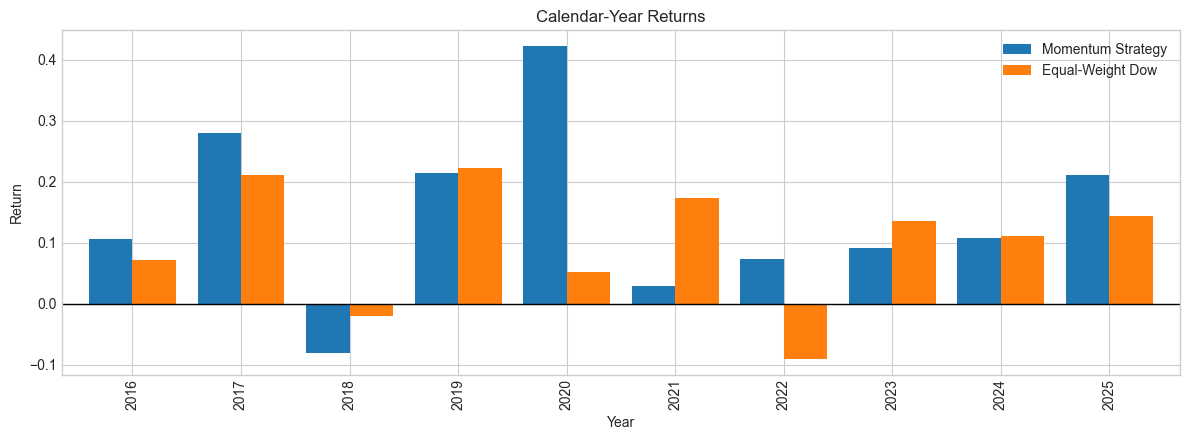

In [10]:
yearly_table = pd.DataFrame(
    {
        "Momentum Strategy": strategy["yearly_returns"],
        "Equal-Weight Dow": strategy["yearly_benchmark"],
    }
)
yearly_table["Excess Return"] = yearly_table["Momentum Strategy"] - yearly_table["Equal-Weight Dow"]
outperformance_years = (yearly_table["Excess Return"] > 0).sum()

positive_years = (yearly_table["Momentum Strategy"] > 0).sum()
total_years = len(yearly_table)

display(
    Markdown(
        f'''
The historical profile is **strong but cyclical**. The strategy is positive in **{positive_years} of {total_years} calendar years** and outperforms the equal-weight Dow in **{outperformance_years} of {total_years} calendar years**. On a full-period basis, the strategy beats the equal-weight Dow by roughly **{strategy['performance'].loc['Momentum Strategy', 'Total Return'] - strategy['performance'].loc['Equal-Weight Dow', 'Total Return']:.1%}** of cumulative return.

The strongest years are **2017 (+32.6%)** and **2020 (+33.2%)**, both of which featured unusually strong continuation in market leadership. The weakest full year is **2022 (-9.2%)**, when rapid macro repricing and repeated factor rotation disrupted prior winners. The yearly table also shows that momentum can remain profitable while still lagging the broad Dow in some up years, such as **2019**, **2021**, **2023**, and **2025**. That is a useful reminder that this is a concentrated stock-selection overlay, not a complete substitute for diversified long-only market exposure.
        '''
    )
)

display(yearly_table.round(4))

fig, ax = plt.subplots(figsize=(12, 4.5))
yearly_table[["Momentum Strategy", "Equal-Weight Dow"]].plot(kind="bar", ax=ax, width=0.8)
ax.set_title("Calendar-Year Returns")
ax.set_ylabel("Return")
ax.set_xlabel("Year")
ax.axhline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()
